In [1]:
# Initialize libraries
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

os.chdir('/home/kaseng/warehouse/data/')

In [23]:
# Load data
comp_trial_1 = np.load("./composite_trial_2.npy")
pure_trial_1 = np.load("./pure_trial_1.npy")
separated_trial_3 = np.load("./separated_trial_3.npy") 

composite_cmds = np.load("./composite_cmds.npy")
separated_cmds = np.load("./separated_cmds.npy")

composite_values = np.load("./composite_values.npy")[0]
print(composite_values.shape)


(999, 5)


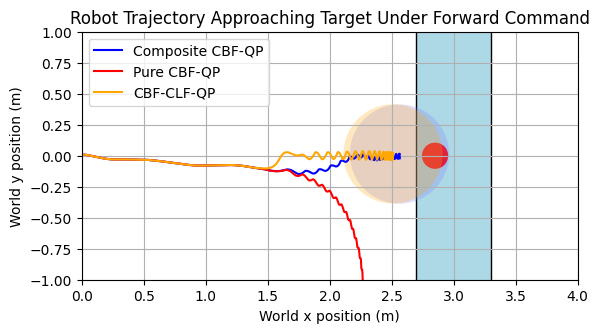

In [ ]:
# Trajectory plots for obstacle

data_threshold = 10000

fig, ax = plt.subplots()

rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor='lightblue')
circle_target = Circle((2.85, 0.0), radius=0.1, edgecolor="red", facecolor="red")
circle_composite = Circle((comp_trial_1[data_threshold-1, :2]), radius=0.4, facecolor=(0.5,0.5,1.0,0.25))
circle_separate_1 = Circle((pure_trial_1[data_threshold-1,:2]), radius=0.4, facecolor=(1, 0, 0, 0.25))
circle_separate_3 = Circle((separated_trial_3[data_threshold-1,:2]), radius=0.4, facecolor=(1.0,0.65,0,0.25))
ax.add_patch(rect)
ax.add_patch(circle_target)
ax.add_patch(circle_composite)
ax.add_patch(circle_separate_1)
ax.add_patch(circle_separate_3)

ax.plot(comp_trial_1[:data_threshold,0], comp_trial_1[:data_threshold,1], color="b", label="Composite CBF-QP")
ax.plot(pure_trial_1[:data_threshold,0], pure_trial_1[:data_threshold,1], color="r", label="Pure CBF-QP")
ax.plot(separated_trial_3[:data_threshold,0], separated_trial_3[:data_threshold,1], color=(1.0,0.65,0), label="CBF-CLF-QP")

ax.set_xlim(0, 4)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')
plt.grid(True)
plt.title('Robot Trajectory Approaching Target Under Forward Command')
plt.xlabel("World x position (m)")
plt.ylabel("World y position (m)")
plt.legend()
plt.show()

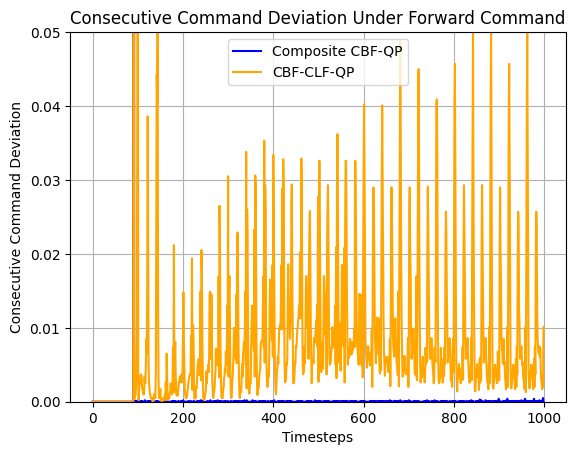

In [12]:
# Consecutive command error (squared error)

def consecutive_command_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - prev_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

fig, ax = plt.subplots()

ax.plot(range(np.size(composite_cmds,axis=0)), consecutive_command_change(composite_cmds), color="b", label="Composite CBF-QP")
ax.plot(range(np.size(separated_cmds,axis=0)), consecutive_command_change(separated_cmds), color=(1.0,0.65,0), label="CBF-CLF-QP")
ax.set_ylim(0, 0.05)
plt.title('Consecutive Command Deviation Under Forward Command')
plt.xlabel("Timesteps")
plt.ylabel("Consecutive Command Deviation")
plt.grid(True)
plt.legend()
plt.show()


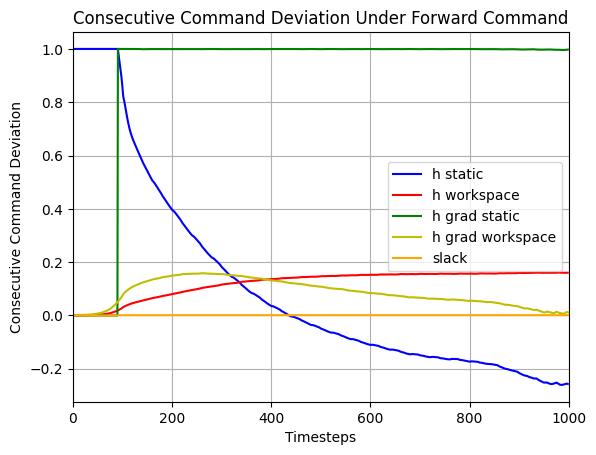

In [ ]:
# CBF values
# [cbf.h_static_obs, cbf.h_workspace, np.linalg.norm(cbf.grad_h_static_obs), np.linalg.norm(cbf.grad_h_workspace), cbf.moving_slack]
fig, ax = plt.subplots()

h_static = composite_values[:, 0]
h_workspace = composite_values[:, 1]
h_grad_static = composite_values[:, 2]
h_grad_workspace = composite_values[:, 3]
h_slack = composite_values[:, 4]

ax.plot(range(np.size(composite_values,axis=0)), h_static, color="b", label="h static")
ax.plot(range(np.size(composite_values,axis=0)), h_workspace, color="r", label="h workspace")
ax.plot(range(np.size(composite_values,axis=0)), h_grad_static, color="g", label="h grad static")
ax.plot(range(np.size(composite_values,axis=0)), h_grad_workspace, color="y", label="h grad workspace")
ax.plot(range(np.size(composite_values,axis=0)), h_slack, color=(1.0,0.65,0), label="slack")
plt.title('Consecutive Command Deviation Under Forward Command')
plt.xlabel("Timesteps")
plt.ylabel("Composite CBF Values")
ax.set_xlim(0, 1000)
plt.grid(True)
plt.legend()
plt.show()